In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load Titanic data 
df = pd.read_csv("train.csv")

# Quick clean - fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)

print("Titanic data loaded:", df.shape)
print("Columns:", df.columns.tolist())

Titanic data loaded: (891, 11)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


## How many survived vs died?


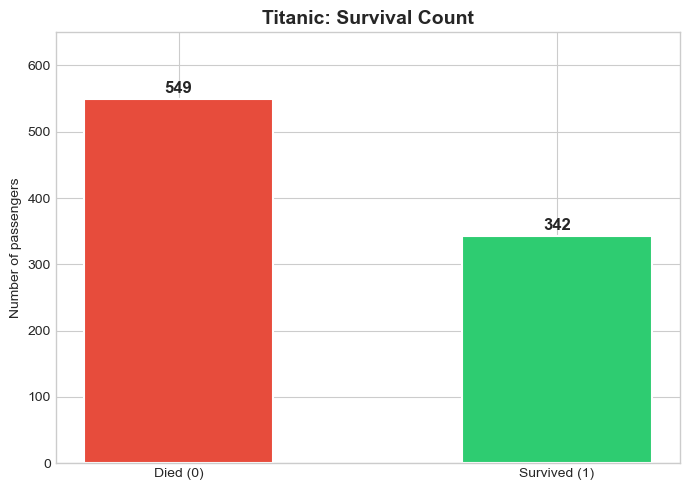

Bar chart done!


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

survival_counts = df['Survived'].value_counts().sort_index()
bars = ax.bar(['Died (0)', 'Survived (1)'], 
             survival_counts.values,
             color=['#e74c3c','#2ecc71'],
             edgecolor='white', linewidth=1.5, width=0.5)

#Add count labels on top of bars
for bar, count in zip(bars, survival_counts.values) :
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
           str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Titanic: Survival Count', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of passengers')
ax.set_ylim(0, 650)
plt.tight_layout()
plt.savefig('chart1_survival_count.png', dpi=100)
plt.show()
print("Bar chart done!")


### Insight
The chart illustrates that a significantly higher number of passengers died (549) compared to those who survived (342), indicating a low overall survival rate on the Titanic. This suggests that survival was limited and may have been influenced by factors such as class, gender, or across to lifeboats.

## Which gender survived more?

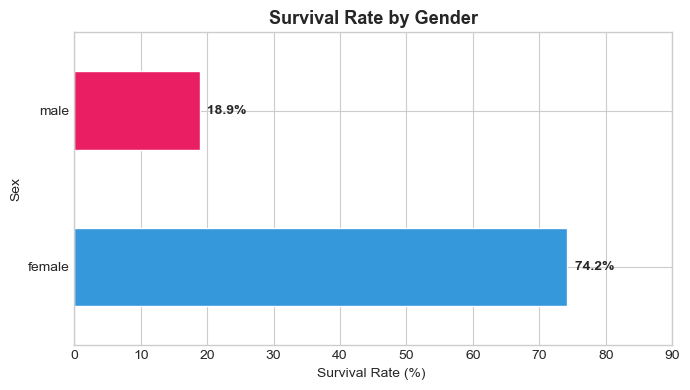

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(7,4))

gender_survival = df.groupby('Sex')['Survived'].mean() * 100 

gender_survival.plot(
    kind='barh',
    ax=ax,
    color=['#3498db', '#e91e63'],
    edgecolor='white'
)

for i, v in enumerate(gender_survival.values):
    ax.text(v + 0.5, i, f'{v: .1f}%', va='center', fontweight='bold')
    
ax.set_title('Survival Rate by Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Survival Rate (%) ' )
ax.set_xlim(0, 90)
plt.tight_layout()
plt.savefig('chart2_gender.png', dpi=100)
plt.show()
print(gender_survival)

### Insight 
The chart shows a significant disparity in survival rates between genders, with females having a much higher survival rate (74.2%) compare to males (18.9%). This suggests that gender played a critical role in survival, possibly due to priority rescue protocols such as "women and children first".

## How are passenger ages distributed?

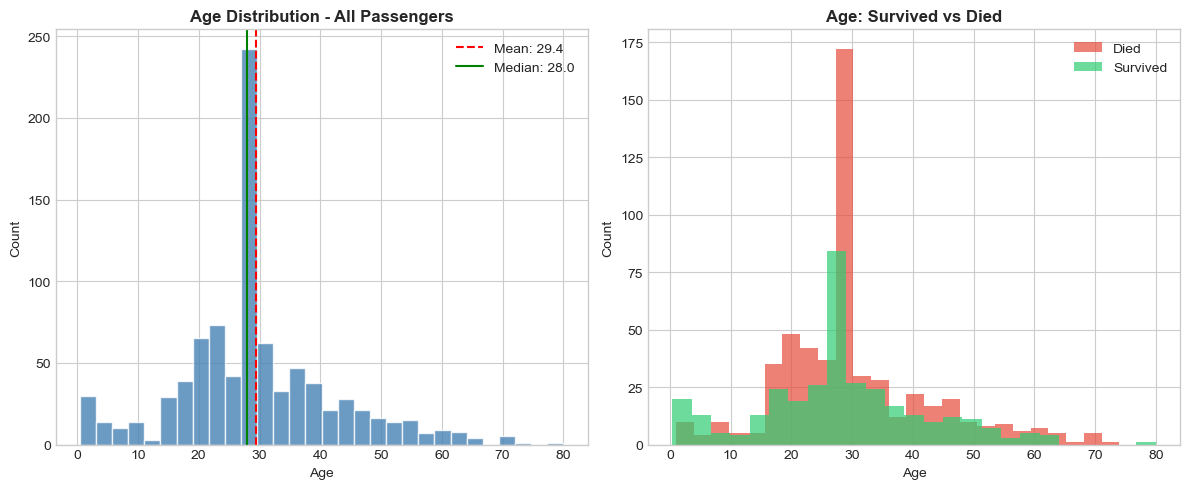

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Left chart: all passengers
axes[0].hist(df['Age'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Age Distribution - All Passengers', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='-', label=f'Median: {df["Age"].median():.1f}')
axes[0].legend()

#Survivors vs Non-survivors
survived = df[df['Survived'] == 1]['Age']
died = df[df['Survived'] == 0]['Age']
axes[1].hist(died, bins=25, alpha=0.7, color='#e74c3c', label='Died')
axes[1].hist(survived, bins=25, alpha=0.7, color='#2ecc71', label='Survived')
axes[1].set_title('Age: Survived vs Died', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart3_age_histogram.png', dpi=100)
plt.show()

### Insight
The distribution shows a concentration pf passengers in the 20-35 age range, with a slight right skew. The survival comparison indicates taht mortality rates were consistently higher across age groups, but younger passengers appear to have relatively better survival outcomes. This suggests that age, along with other factors, may have played a role in survival likelihood.


## Which colomns are related to each other?


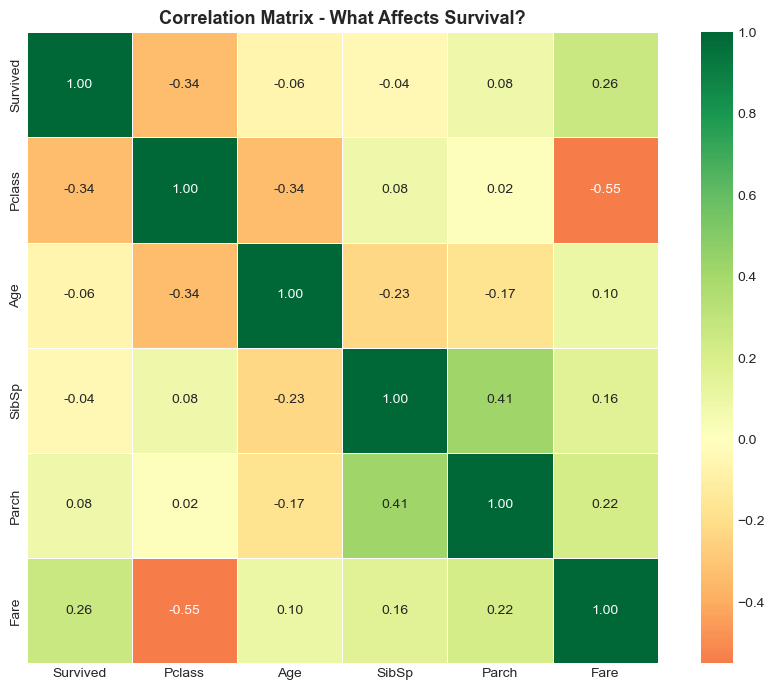

Correlation values:
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.06  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.34   0.08   0.02 -0.55
Age          -0.06   -0.34  1.00  -0.23  -0.17  0.10
SibSp        -0.04    0.08 -0.23   1.00   0.41  0.16
Parch         0.08    0.02 -0.17   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00


In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare' ]

corr_matrix = df[numeric_cols].corr()


sns.heatmap(
    corr_matrix,
    annot=True,    # Show number in cells
    fmt='.2f',     # 2 decimal places
    cmap='RdYlGn', # Red-Yellow-Green colour scales
    center=0,      # Centre at 0
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix - What Affects Survival?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=100)
plt.show()
print('Correlation values:')
print(corr_matrix.round(2))

### Insight
The correlation matrix indicates that survival is moderately negatively correlated with passenger class (-0.34) and positively correlated with fare (0.26), suggesting that passengers in higher socioeconomic classes had better survival chances. Other factors such as age, number of siblings/Spouses, and Parents/children show weak correlations, indicating they had limited influence on survival outcomes.

## SURVIVAL BY CLASS AND GENDER

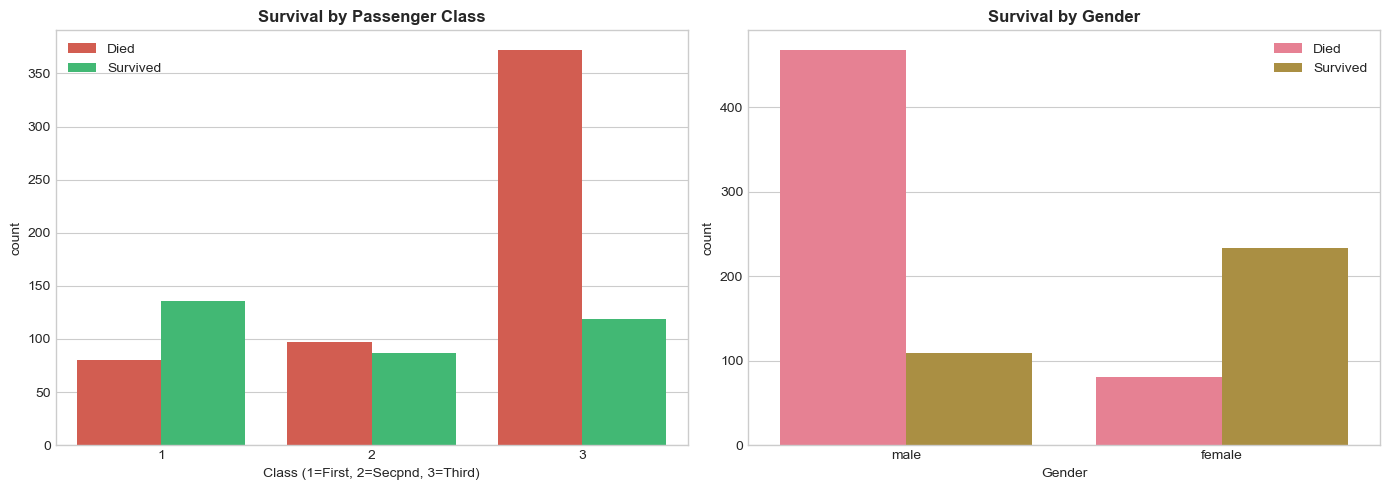

In [9]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))

# Left chart: Survival by passenger class
sns.countplot(data=df,x='Pclass', hue='Survived', palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[0])

axes[0].set_title('Survival by Passenger Class', fontweight='bold')

axes[0].set_xlabel('Class (1=First, 2=Secpnd, 3=Third)')

axes[0].legend(['Died', 'Survived'])

#Right chart: Survival by gender
sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    ax=axes[1]
)

axes[1].set_title('Survival by Gender', fontweight='bold')

axes[1].set_xlabel('Gender')

axes[1].legend(['Died', 'Survived'])

plt.tight_layout()
plt.savefig('chart5_countplot.png', dpi=100)
plt.show()

### Insight
The chart indicate that both passenger class and gender significantly influenced survival outcomes. First-class passengers show higher survival counts compared to third-class passengers, where deaths are predominant. Additionally, females have a substantially higher survival rate than males. This suggests that socioeconomic status and gender played a critical role in determining survival, possibly due to priority access to lifeboats and rescue efforts. 

## Does paying more or being older affect survival?

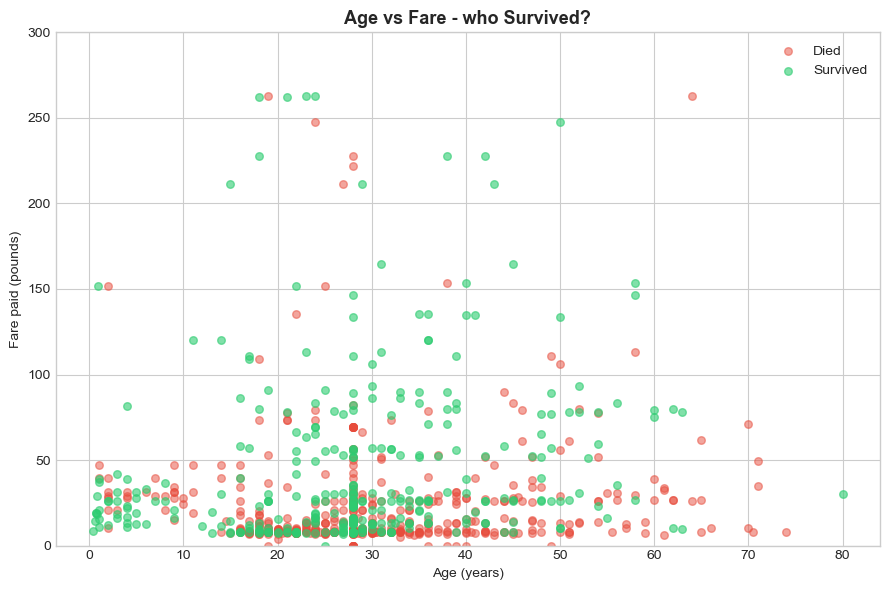

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

survived_group = df[df['Survived'] == 1]

died_group = df[df['Survived'] == 0]

ax.scatter(died_group['Age'], died_group['Fare'], c='#e74c3c', alpha=0.5, label='Died', s=30)

ax.scatter(survived_group['Age'], survived_group['Fare'], c='#2ecc71', alpha=0.6, label='Survived', s=30)

ax.set_title('Age vs Fare - who Survived?', fontsize=13, fontweight='bold')

ax.set_xlabel('Age (years)')

ax.set_ylabel('Fare paid (pounds)')

ax.legend()

ax.set_ylim(0, 300)

plt.tight_layout()
plt.savefig('chart6_scatter.png', dpi=100)
plt.show()

### Insight
The scatter plot shows that passengers who paid higher fares had a higher likelihood of survival, as indicated by the concentration of survivors in the higher fare range. In contrast, most passengers who paid lower fares had a higher death rate. Age does not show a strong pattern, suggesting that fare (a proxy for class) had a greater influence on survival than age.


## FULL DASHBOARD: ALL INSIGHTS TOGETHER

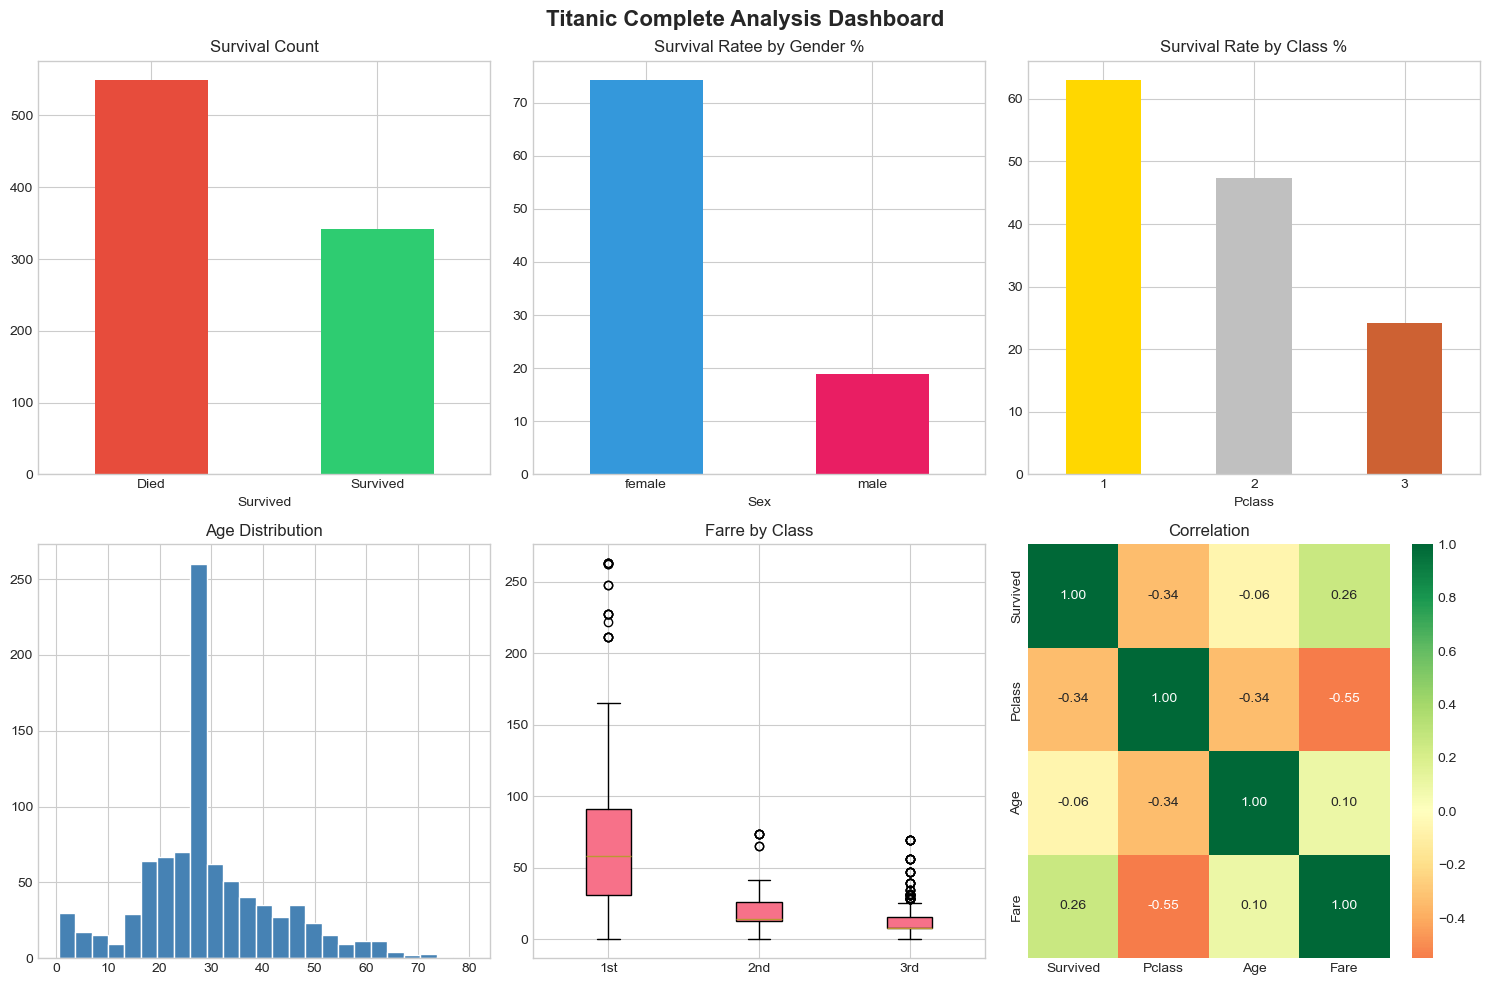

Dashboard saved!


In [11]:
fig = plt.figure(figsize=(15, 10))

fig.suptitle('Titanic Complete Analysis Dashboard', fontsize=16, fontweight='bold')

# Chart 1: survival xount (top left)
ax1 = fig.add_subplot(2, 3, 1)

df['Survived'].value_counts().sort_index().plot(kind='bar', ax=ax1, color=['#e74c3c', '#2ecc71'], rot=0)
ax1.set_title('Survival Count')
ax1.set_xticklabels(['Died', 'Survived'])

# Chart 2: gender survival rate (top middle)
ax2 = fig.add_subplot(2, 3, 2)
(df.groupby('Sex')['Survived'].mean()*100).plot(kind='bar', ax=ax2, color=['#3498db', '#e91e63'], rot=0)
ax2.set_title('Survival Ratee by Gender %')

# Chart 3: class survival rate (top right)
ax3 = fig.add_subplot(2, 3, 3)
(df.groupby('Pclass')['Survived'].mean()*100).plot(kind='bar', ax=ax3, color=['gold', 'silver', '#cd6133'], rot=0)
ax3.set_title('Survival Rate by Class %')

# Chart 4: age histogram (bottom left)
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(df['Age'], bins=25, color='steelblue', edgecolor='white')
ax4.set_title('Age Distribution')

# Chart 5: fare box plot (bottom middle)
ax5 = fig.add_subplot(2, 3, 5)
df_c = df[df['Fare'] < 300]
ax5.boxplot([df_c[df_c['Pclass']==i]['Fare'].values for i in [1,2,3]], labels=['1st', '2nd', '3rd'], patch_artist=True)
ax5.set_title('Farre by Class')

# Chart 6: heatmap (bottom right)
ax6 = fig.add_subplot(2, 3, 6)
corr = df[['Survived', 'Pclass', 'Age', 'Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax6)
ax6.set_title('Correlation')

plt.tight_layout()
plt.savefig('titanic_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print('Dashboard saved!')

### Insight
The dashboard provides acomprehensive of factors affecting survival on the Titanic. It shows that survival rates were higher among females and first-class passengers, indicating the influence of gender and socioeconomic status. The age distribution suggests that most passengers were young adults, while the fare analysis confirms that higher-paying passengers had better survival chances. Additionaly, the correlation heatmap supports these findings, showing a negative relationship between class and survival and a positive relationship between fare and survival. Overall, survival was strongly influenced by class, gender, and fare rarher than age.